In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
pip install pandas

In [3]:
df = pd.read_csv(r"/content/drive/MyDrive/Banking.csv")

In [4]:
df

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,IND66827,Earl Hall,82,8760,09-10-2014,Joshua Bennett,American,Accounting Assistant III,High,Gold,...,1089957.03,532867.88,657849.62,12947.31,1238859.91,1,3,3,2,4
2996,IND40556,Billy Williamson,44,32837,05-02-2009,Dennis Ruiz,European,Paralegal,Mid,Gold,...,136891.32,56581.74,93195.61,23205.69,277171.07,1,2,3,2,5
2997,IND72414,Victor Black,70,36088,29-12-2009,Joshua Ryan,American,Statistician IV,Low,Jade,...,214860.89,158726.06,35539.15,30291.81,502947.22,2,2,3,2,6
2998,IND46652,Andrew Ford,56,24871,13-02-2006,Nicholas Cunningham,European,Human Resources Assistant III,Mid,Jade,...,742630.22,404638.26,56411.33,6413.14,1538368.60,3,1,3,2,7


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

,0
Client ID,0
Name,0
Age,0
Location ID,0
Joined Bank,0
Banking Contact,0
Nationality,0
Occupation,0
Fee Structure,0
Loyalty Classification,0


In [7]:
df.shape

(3000, 25)

In [8]:
df.head()

,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [9]:
df.columns

Index(['Client ID', 'Name', 'Age', 'Location ID', 'Joined Bank',
       'Banking Contact', 'Nationality', 'Occupation', 'Fee Structure',
       'Loyalty Classification', 'Estimated Income', 'Superannuation Savings',
       'Amount of Credit Cards', 'Credit Card Balance', 'Bank Loans',
       'Bank Deposits', 'Checking Accounts', 'Saving Accounts',
       'Foreign Currency Account', 'Business Lending', 'Properties Owned',
       'Risk Weighting', 'BRId', 'GenderId', 'IAId'],
      dtype='object')

In [10]:
df.drop(columns=["Location ID","Risk Weighting","BRId","IAId","Name"],inplace=True)

In [11]:
df['GenderId'] = df['GenderId'].replace({1: 'Male', 2: 'Female'})

In [12]:
df['GenderId']

,GenderId
0,Male
1,Male
2,Female
3,Male
4,Female
...,...
2995,Female
2996,Female
2997,Female
2998,Female


In [13]:
df.dtypes

,0
Client ID,object
Age,int64
Joined Bank,object
Banking Contact,object
Nationality,object
Occupation,object
Fee Structure,object
Loyalty Classification,object
Estimated Income,float64
Superannuation Savings,float64


In [14]:
# Which geography has highest churn?
df.groupby("Nationality")["Bank Deposits"].sum()

,Bank Deposits
Nationality,
African,1.210648e+08
American,3.353003e+08
Asian,5.153119e+08
Australian,1.690381e+08
European,8.739655e+08


In [16]:
# Which products are most used?
df.groupby("Nationality")["Bank Deposits"].count()

,Bank Deposits
Nationality,
African,176
American,507
Asian,754
Australian,254
European,1309


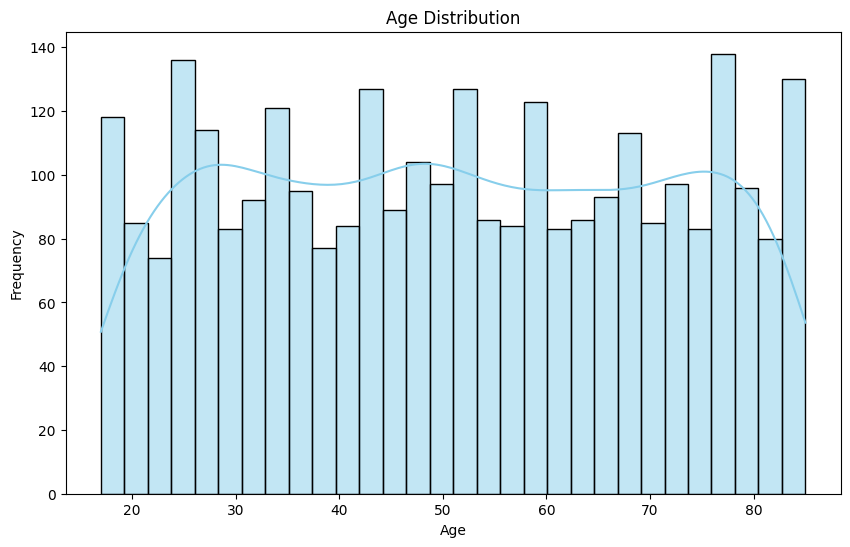

In [18]:
# age distribution?
plt.figure(figsize = (10,6))
sns.histplot(df["Age"], kde=True, bins = 30, color="skyblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

/tmp/ipykernel_2339/2171704997.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='GenderId', data=df, palette='Set2')


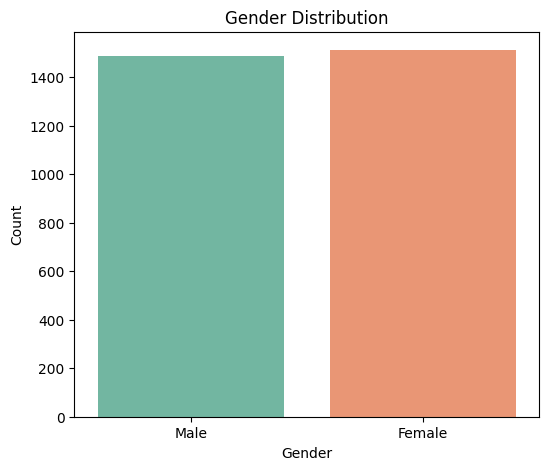

In [19]:
#Gender ID Classification
plt.figure(figsize=(6, 5))
sns.countplot(x='GenderId', data=df, palette='Set2')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_2339/3750093953.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Loyalty Classification', palette='Set2')


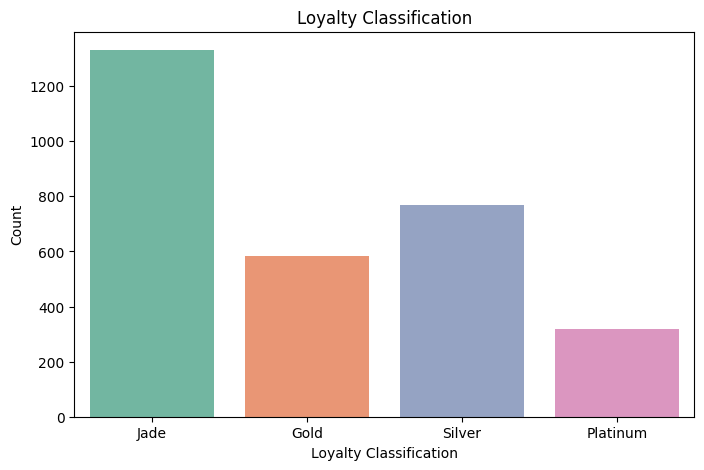

In [20]:
#Lyalty Classification
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Loyalty Classification', palette='Set2')
plt.title('Loyalty Classification')
plt.xlabel('Loyalty Classification')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_2339/3087837119.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Nationality', palette='Set2')


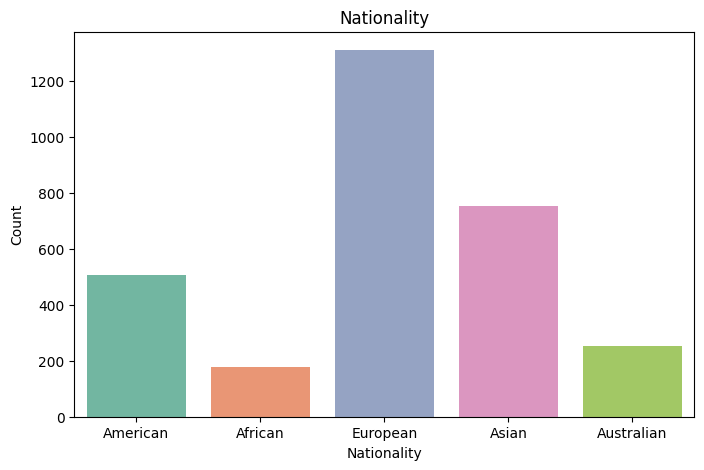

In [21]:
# Nationlality Classification
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Nationality', palette='Set2')
plt.title('Nationality')
plt.xlabel('Nationality')
plt.ylabel('Count')
plt.show()

/tmp/ipykernel_2339/2595998975.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['Occupation'].isin(top_occupations)],


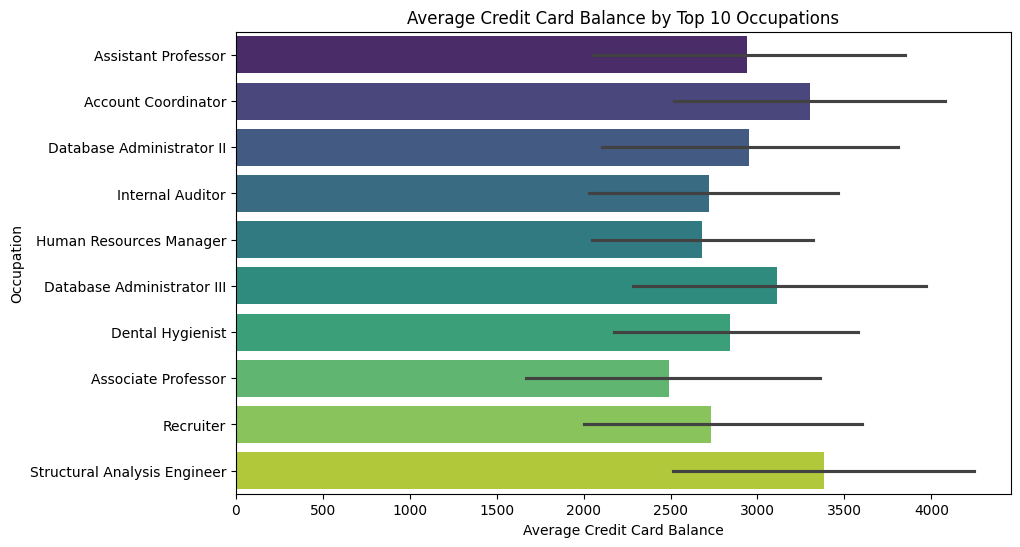

In [25]:
import numpy as np

top_occupations = df['Occupation'].value_counts().nlargest(10).index

plt.figure(figsize=(10, 6))
sns.barplot(data=df[df['Occupation'].isin(top_occupations)],
            x='Credit Card Balance', y='Occupation',
            estimator=np.mean, palette='viridis')
plt.title('Average Credit Card Balance by Top 10 Occupations')
plt.xlabel('Average Credit Card Balance')
plt.ylabel('Occupation')
plt.show()

**UNIVARIATE ANALYSIS**

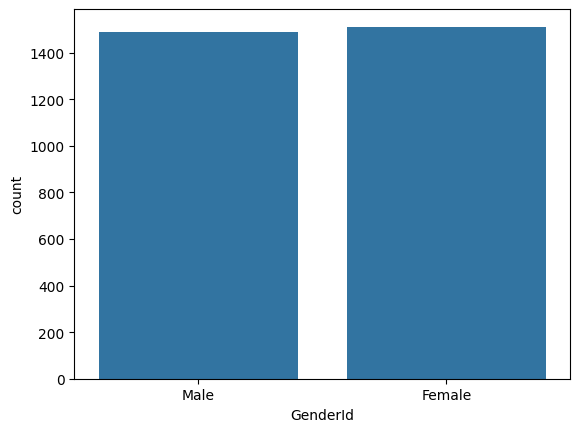

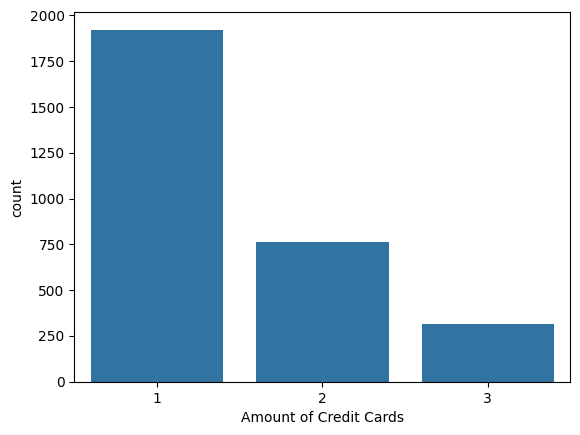

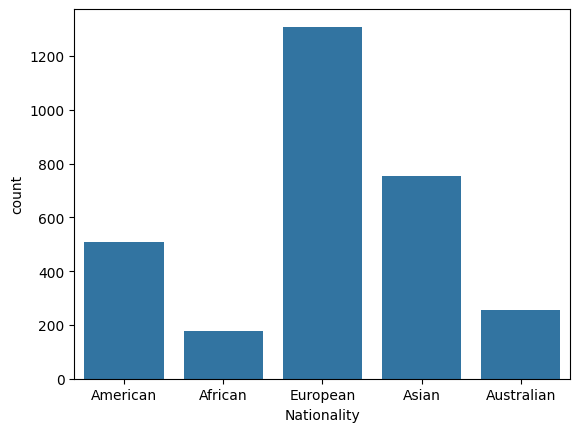

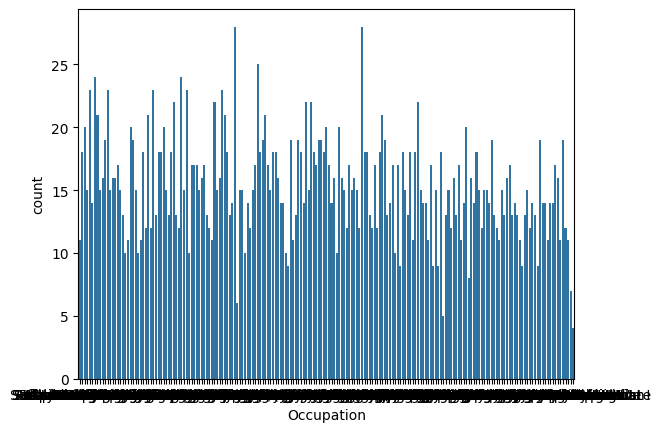

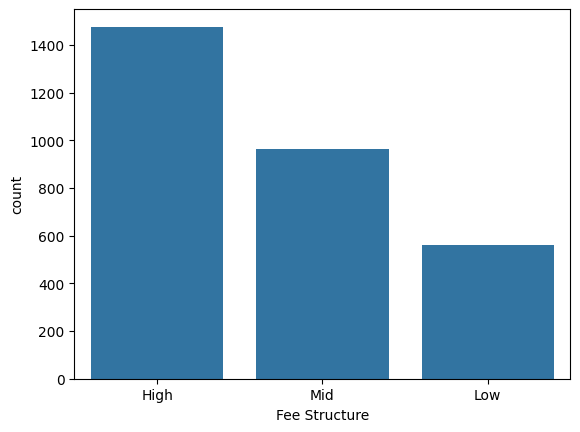

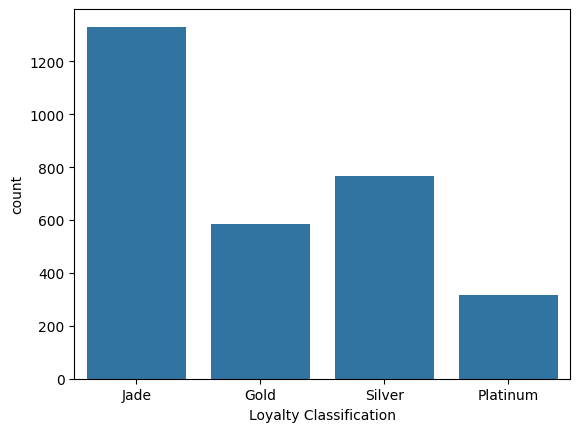

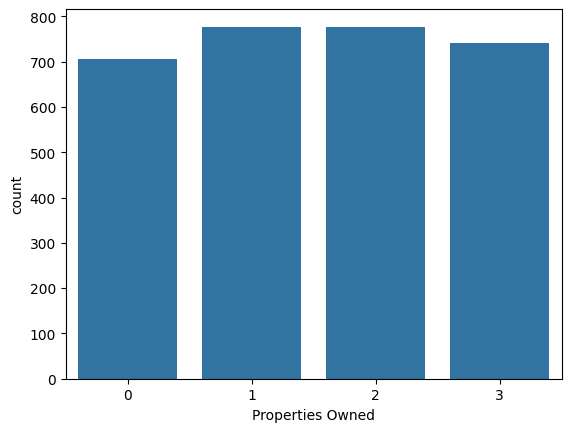

In [28]:
for i, predictor in enumerate(df[[ "GenderId", "Amount of Credit Cards", "Nationality", "Occupation", "Fee Structure", "Loyalty Classification", "Properties Owned"]].columns):
    plt.figure(i)
    sns.countplot(data=df, x=predictor)

In [33]:
# Examine the distribution of unique cataegories in categorical columns
categorical_cols = df[[ "GenderId", "Amount of Credit Cards", "Nationality", "Occupation", "Fee Structure", "Loyalty Classification", "Properties Owned"]].columns

for col in categorical_cols:
  print(f"Value Counts for '{col}':")
  display(df[col].value_counts())

Value Counts for 'GenderId':


,count
GenderId,
Female,1512
Male,1488


Value Counts for 'Amount of Credit Cards':


,count
Amount of Credit Cards,
1,1922
2,765
3,313


Value Counts for 'Nationality':


...

,count
Fee Structure,
High,1476
Mid,962
Low,562


Value Counts for 'Loyalty Classification':


,count
Loyalty Classification,
Jade,1331
Silver,767
Gold,585
Platinum,317


Value Counts for 'Properties Owned':


,count
Properties Owned,
2,777
1,776
3,742
0,705


**BIVARIATE ANALYSIS**

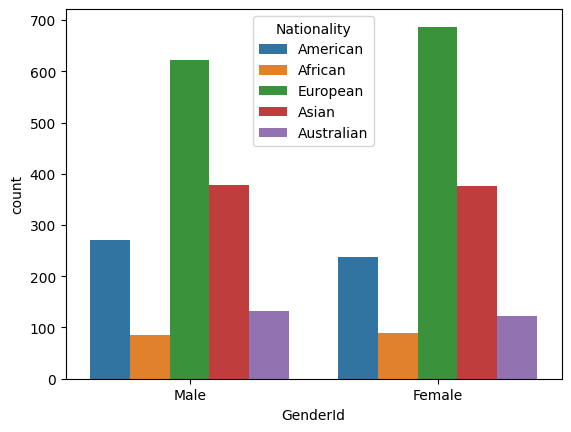

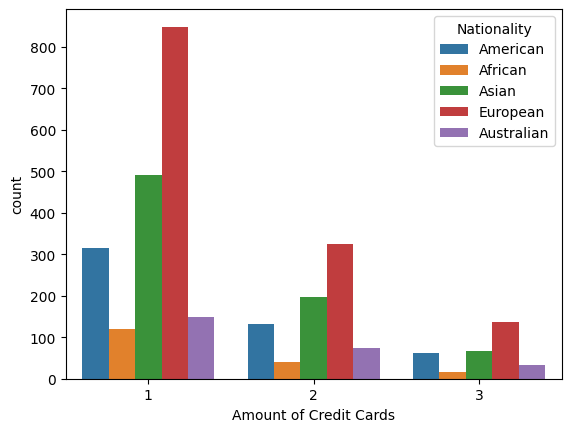

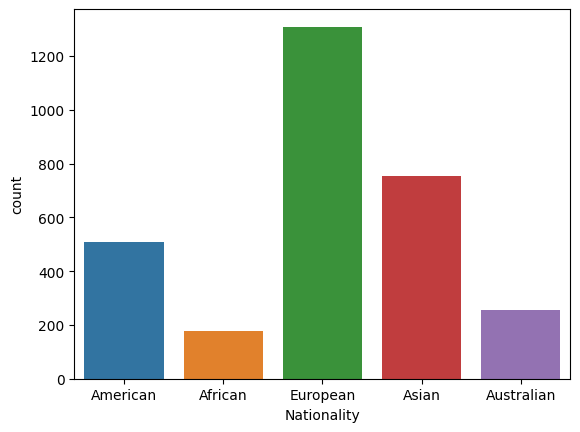

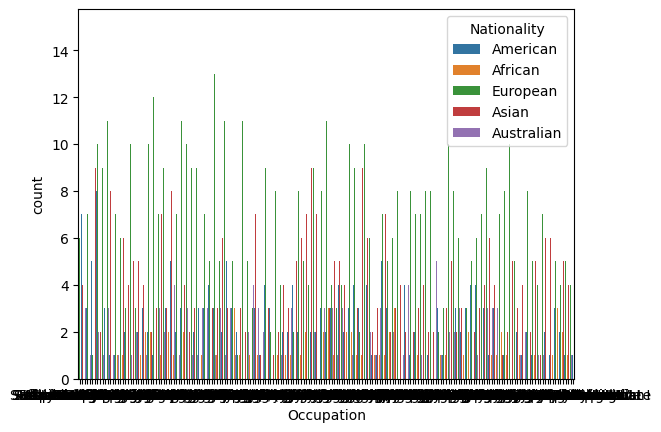

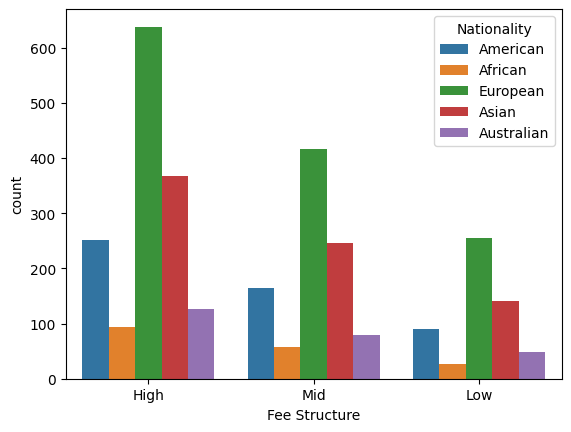

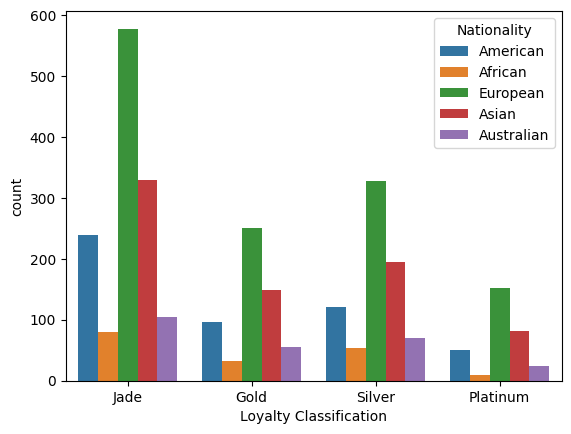

In [35]:
for i, predictor in enumerate(df[[ "GenderId", "Amount of Credit Cards", "Nationality", "Occupation", "Fee Structure", "Loyalty Classification"]].columns):
    plt.figure(i)
    sns.countplot(data=df, x=predictor, hue='Nationality')

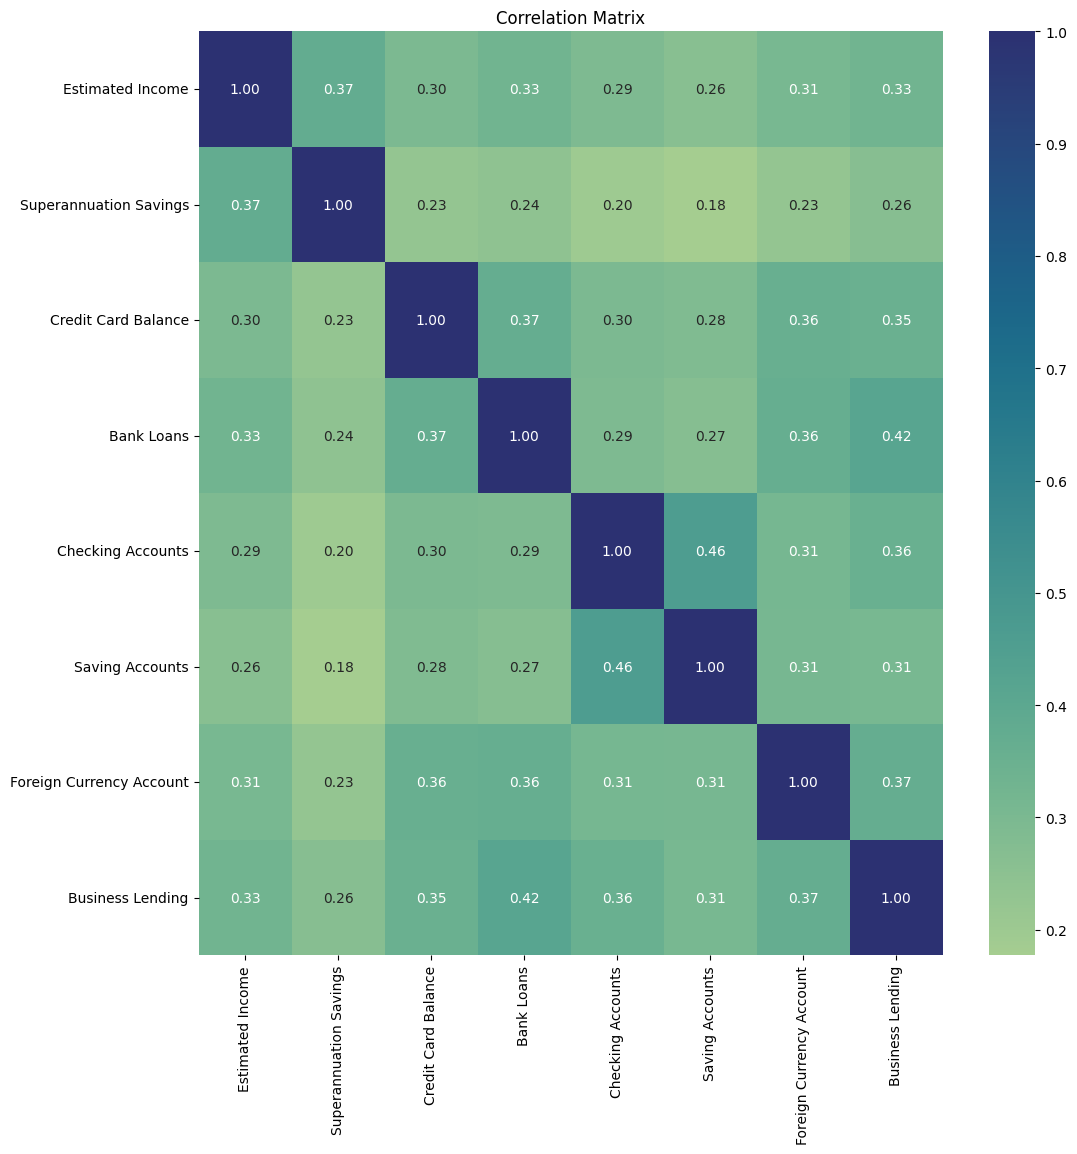

In [36]:
numerical_cols = ['Estimated Income', 'Superannuation Savings', 'Credit Card Balance', 'Bank Loans', 'Checking Accounts', 'Saving Accounts', 'Foreign Currency Account', 'Business Lending']

correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12,12))
sns.heatmap(correlation_matrix, annot=True, cmap='crest', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()